# ✦ Technical Deep-Dive: LLM Core Architectures & API Operations
> **Reference Stack:** Cross-compiled from OpenAI Documentation, Anthropic Frameworks, Google Vertex AI Specs, and Modern Transformer Benchmarks.

### 1. What are LLMs?
*   **Transformer Architecture Basics:** Modern LLMs run on the Transformer architecture (Vaswani et al.). It replaced sequential processing (RNNs/LSTMs) with a highly parallelizable design. It uses positional encodings to process entire text structures simultaneously, utilizing an **Encoder** (for compression/understanding) and a **Decoder** (for auto-regressive generation).
*   **Attention Mechanism:** The core engine is **Multi-Head Self-Attention**. Mathematically, it calculates how much "focus" every word needs to place on every other word in a sequence. It translates tokens into vectors of Queries ($Q$), Keys ($K$), and Values ($V$), computing context via a scaled dot-product:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

*   **Pre-training vs Fine-tuning:** 
    *   *Pre-training:* The model reads massive unlabeled datasets (web scrapes, books) to learn basic grammar, world knowledge, and statistical word associations (Self-Supervised Learning).
    *   *Fine-tuning:* The pre-trained base model is trained on small, curated, instruction-response pairs (Supervised Fine-Tuning - SFT) and human feedback (RLHF) to make it safe, conversational, and task-oriented.

### 2. Major LLM Providers (Production Profile)

| Provider | Core Flagship Model | Primary Structural Strength | Native Edge / Ecosystem |
| :--- | :--- | :--- | :--- |
| **OpenAI** | GPT-4o / o1 Series | Structured JSON outputs, fast inference, agentic reasoning. | Deeply integrated into Azure & MS ecosystem. |
| **Anthropic** | Claude 3.5 Sonnet / Opus | Complex logic execution, source code synthesis, safety. | Constitutional AI (built-in ethical boundary mapping). |
| **Google** | Gemini 1.5 Pro / 2.0 | Natively multimodal (Text, Audio, Video, Code simultaneously). | 1M+ Massive Context Window & Google Workspace integration. |


### 3. Key Operational Concepts
*   **Tokens:** The basic linguistic currency. Words are parsed into character fragments called tokens ($1 \text{ token} \approx 0.75 \text{ words}$ or 4 characters).
*   **Context Window:** The rigid memory limit of the model. It defines the maximum combined capacity of input tokens (prompt) + output tokens (response) that the model can hold in attention at one time.
*   **Temperature:** A scaling factor applied to the model's final token probability layer. Low values make the model stick strictly to the highest probability words, while high values scatter the focus, increasing random variations.

In [ ]:
# Installing core production toolkits for LLM pipeline simulation
!pip install openai python-dotenv rich --break-system-packages

import os
import math
from dotenv import load_dotenv
from rich.console import Console
from rich.panel import Panel
from rich.table import Table

console = Console()
load_dotenv()

print("✅ Analytics environment and dependencies successfully configured.")

In [ ]:
# Executing Parameter Experiments
prompt_temp = "Complete this phrase with a creative twist: 'The ancient code...'"

# 1. Temperature Testing
temp_0 = run_experiment(prompt_temp, temp=0.0)
temp_7 = run_experiment(prompt_temp, temp=0.7)
temp_15 = run_experiment(prompt_temp, temp=1.5)

# 2. Max Tokens Truncation Testing
prompt_trunc = "Write a highly detailed explanation of machine learning."
trunc_short = run_experiment(prompt_trunc, max_tok=12)
trunc_mid = run_experiment(prompt_trunc, max_tok=40)

print("🔬 Experiments finished. Compiling empirical data into a production matrix...")

### 4. API Parameters & Production Engineering
When constructing production API payloads, these parameters control the behavior, cost, and design of the output:
*   `max_tokens`: Sets a hard stop on output length to prevent infinite loops and manage API generation costs.
*   `temperature`: Controls output variance ($0.0 = \text{deterministic/math}$, $1.0+ = \text{creative/fiction}$).
*   `top_p` (Nucleus Sampling): Filters the token options pool based on cumulative probability weight (e.g., $0.1$ means only look at the top 10% most likely words). *Tip: Don't alter both temperature and top_p at the same time.*
*   `frequency_penalty`: Penalizes tokens based on how many times they have *already appeared* in the text. Directly prevents repetitive sentences or phrases.
*   `presence_penalty`: Penalizes tokens based on whether they have appeared *at all*. Forces the model to introduce completely new topics and vocabulary.

### 5. Practical Use Cases vs. System Limitations

#### Target Deployment Vector Space
1.  **Text Generation:** Drafting newsletters, specialized email threads, documentation frameworks.
2.  **Summarization:** Shrinking long legal or financial documents into a list of key takeaways.
3.  **Classification:** Scanning customer support messages to instantly label them as "Urgent" or "Billing".
4.  **Q&A Engines:** Building intelligent search systems (RAG) over internal company knowledge bases.
5.  **Code Generation:** Writing boilerplate scripts, generating unit tests, and debugging error logs.
6.  **Translation:** Localizing content across multiple languages while preserving regional context and tone.

#### Core Technical Limitations & System Boundaries
*   ⚠️ **Hallucinations:** LLMs generate words based on mathematical patterns, not actual reality. They can confidently invent fake citations, legal cases, or API libraries.
*   ⚠️ **Knowledge Cutoff:** Models cannot answer questions about real-world events that occurred after their training period ended, unless connected to a live web search tool.
*   ⚠️ **Context Degradation:** If an input file exceeds the model's context window, older data is forgotten. Long context can also cause a "lost in the middle" problem, where the model misses details buried in the middle of long texts.
*   ⚠️ **Reasoning Failures:** While LLMs excel at matching language patterns, they frequently struggle with advanced logic puzzles, multi-step planning, and complex math.

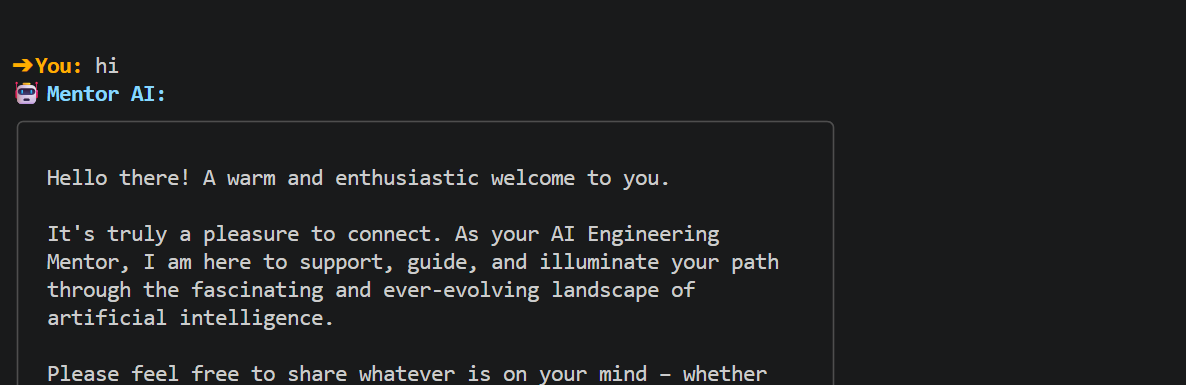